In [164]:
import numpy as np
import random


In [165]:
def f_identity(A):
    return A

def f_identity_der(A):
    return 1

def f_sigmoid(A):
    # Vectorized function
    s = np.where(A>0, 1/(1+np.exp(-A)), np.exp(A)/(1+np.exp(A)))
    return s

def f_sigmoid_der(A):
    s = f_sigmoid(A)
    return s * (1 - s)

     
class hidden_layer:
    def __init__(self, input_dimension, output_dimension, activation_fn, 
                       activation_fn_der, level, lam=0, sigma =0.01):
        self.sigma = sigma
        self.name = "Hidden_layer"
        self.level = level 
        self.lam = lam
        print('lam=',lam)
        self.input_dimension = input_dimension
        self.output_dimension = output_dimension
        self.__activation_fn = activation_fn  
        self.__activation_fn_der = activation_fn_der  
        self.W = np.random.randn(output_dimension,input_dimension) * self.sigma
        self.dW = np.zeros(self.W.shape)
  
    def shape(self):
        return (self.input_dimension, self.output_dimension)
    
    def __linear_activation(self, X):
        return self.W.dot(X)
    
    def __non_linear_activation(self, X):
        Z = self.__activation_fn(X)
        Z[0] = 1 # Clamp to 1
        return Z
    
    def forward(self, Z_prev):
        A  = self.__linear_activation(Z_prev)
        Z  = self.__non_linear_activation(A)
        return Z, A, Z_prev
    
    def backward(self, d_prev, l, layers, caches):
        Z, A, Z_prev = caches[l]
        var = layers[l+1].W.T.dot(d_prev)
        d = np.multiply(var, layers[l].__activation_fn_der(A))
        self.dW = d.dot(Z_prev.T) + self.lam*self.W
        return d    
        
class output_layer:
    def __init__(self, input_dimension, output_dimension, activation_fn, 
                 activation_fn_der, level, lam=0, sigma=0.01):
        self.sigma = sigma
        self.name = "Output_layer"
        self.level = level 
        self.lam = lam
        self.input_dimension = input_dimension
        self.output_dimension = output_dimension
        self.__activation_fn = activation_fn
        self.__activation_fn_der = activation_fn_der
        self.W = np.random.randn(output_dimension,input_dimension) * self.sigma
        self.dW = np.zeros(self.W.shape)
        
    def shape(self):
        return (self.input_dimension, self.output_dimension) 
    
    def __linear_activation(self, X):
        return self.W.dot(X)
    
    def __non_linear_activation(self, A):
        return self.__activation_fn(A)

    def forward(self, Z_prev):       
        A  = self.__linear_activation(Z_prev)
        Z  = self.__non_linear_activation(A)
        return Z, A, Z_prev
    
    def backward(self, target, Z_L, A_L, Z_prev):
        error = Z_L - target 
        d_L = np.multiply(error,self.__activation_fn_der(A_L)) # Hadamard product
        self.dW = d_L.dot(Z_prev.T) + self.lam*self.W #Check batch ops
        return d_L

class mlp: 
    
    def __init__(self, layers_dimensions, sigma = 0.01, lam = 0, verbose = True):
        self.layers_dimensions = layers_dimensions
        self.sigma = sigma
        self.lam = lam
        self.verbose = verbose
        self.layers = []
        for l in range(0, len(layers_dimensions)-2):
            layer = hidden_layer(layers_dimensions[l], layers_dimensions[l+1], f_sigmoid, 
                                 f_sigmoid_der, l+1, self.lam, self.sigma)
            self.layers.append(layer)
        l += 1
        layer = output_layer(layers_dimensions[l], layers_dimensions[l+1], f_sigmoid, 
                             f_sigmoid_der, l+1, self.lam, self.sigma) # classifier output activation function
        self.layers.append(layer)       
        if self.verbose:
            print("MLP:")
            for l in range(0, len(self.layers)-1):
                    print(f"{self.layers[l].name} {self.layers[l].level}, shape: ({self.layers[l].input_dimension} x {self.layers[l].output_dimension})")
           
            # Output layer
            l += 1
            print(f"{self.layers[l].name} {self.layers[l].level}, shape: ({self.layers[l].input_dimension} x {self.layers[l].output_dimension})")
            print("\n")
   
    def backpropagation(self, X, target):
        # Forward propagation
        _, caches = self.forward(X)
        
        # Backward propagation 
        L = len(caches)
        Z, A, Z_prev = caches[L-1]
        d = self.layers[L-1].backward(target, Z, A, Z_prev)
        
        for l in reversed(range(0,len(caches)-1)):
            d_prev = d
            d = self.layers[l].backward(d_prev, l, self.layers, caches) 
        
    def forward(self, X): 
        caches = []
        Z = X
        for layer in self.layers:
            Z, A, Z_prev = layer.forward(Z) 
            caches.append((Z, A, Z_prev))
        return Z, caches
                
    def predict(self, X):
        Z, _ = self.forward(X)
        return Z
      
    def pack(self):
        grads = {}
        for l in range(0,len(self.layers)):
            grads["W" + str(l+1)] = self.layers[l].W
            grads["dW" + str(l+1)] = self.layers[l].dW

        return grads        

In [166]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_circles, make_classification, make_moons
from sklearn.model_selection import train_test_split

# Create a non-separable data set

X0, t = make_moons(noise=0.3, n_samples = 300, random_state=0)
#X0, t =  make_circles(n_samples=100, noise=0.1, factor=0.5, random_state=1)

X = []
for x in X0:
    X.append([1,x[0],x[1]])


X = np.array(X)
t = np.atleast_2d(t).T



X_train, X_test, t_train, t_test = train_test_split(
        X, t, test_size=0.2, random_state=42
    )

X_train = np.atleast_2d(X_train).T
t_train = np.atleast_2d(t_train).T
X_test = np.atleast_2d(X_test).T
t_test = np.atleast_2d(t_test).T


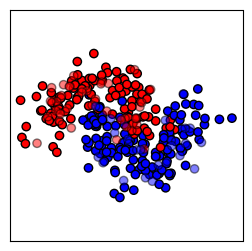

In [167]:
# Plot training and testing data
x_min, x_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
y_min, y_max = X[:, 2].min() - 0.5, X[:, 2].max() + 0.5
h = 0.005

figure = plt.figure(figsize=(3, 3))
cm = plt.cm.RdBu
cm_bright = ListedColormap(["#FF0000", "#0000FF"])
ax = plt.subplot(1, 1, 1)
ax.scatter(X_train.T[:,1], X_train.T[:, 2], c=t_train.T, cmap=cm_bright, edgecolors="k")
ax.scatter(X_test.T[:, 1], X_test.T[:, 2], c=t_test.T, cmap=cm_bright, alpha=0.5, edgecolors="k")
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xticks(())
ax.set_yticks(())
ax.axis('equal');

lam= 0.005
MLP:
Hidden_layer 1, shape: (3 x 40)
Output_layer 2, shape: (40 x 1)


Fitting the model:
epoch:         0, loss: 47.08, %
epoch:       100, loss: 47.08, %
epoch:       200, loss:  20.0, %
epoch:       300, loss: 17.08, %
epoch:       400, loss:  17.5, %
epoch:       500, loss: 18.75, %
epoch:       600, loss: 18.33, %
epoch:       700, loss: 18.33, %
epoch:       800, loss: 18.33, %
epoch:       900, loss: 18.33, %
epoch:      1000, loss: 18.33, %
epoch:      1100, loss: 18.33, %
epoch:      1200, loss: 18.33, %
epoch:      1300, loss: 18.33, %
epoch:      1400, loss: 18.33, %
epoch:      1500, loss: 18.33, %
epoch:      1600, loss: 18.33, %
epoch:      1700, loss: 18.33, %
epoch:      1800, loss: 18.33, %
epoch:      1900, loss: 18.33, %
epoch:      2000, loss: 18.33, %
epoch:      2100, loss: 18.33, %
epoch:      2200, loss: 18.33, %
epoch:      2300, loss: 18.75, %
epoch:      2400, loss: 18.75, %
epoch:      2500, loss: 18.75, %
epoch:      2600, loss: 18.75, %
epoch:  

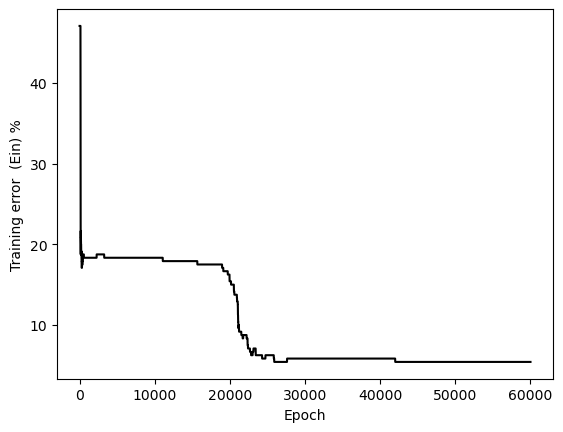

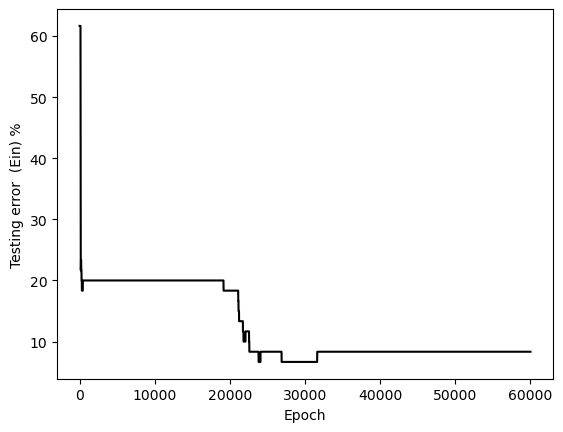

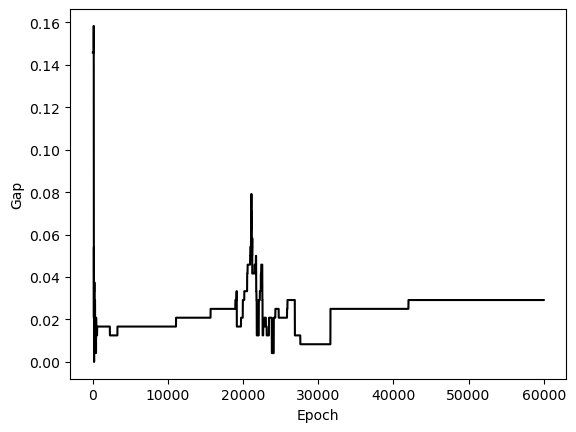

Training accuracy = 94.58333333333333 %
Testing accuracy = 91.67 %


In [184]:

# Learning using batch processing

input_layer_dim = [3]
hidden_layers_dim = [40]
output_layer_dim = [1]
layers_dimensions = input_layer_dim + hidden_layers_dim  + output_layer_dim 

lambda_ = 0.005 # Regularization term
nn = mlp(layers_dimensions, lam = lambda_)

print("Fitting the model:")
alpha = 0.005

epochs = 60000
error = []
ep = []
acc = []
gap = []
for epoch in range(epochs):
    ep.append(epoch)    
    nn.backpropagation(X_train,t_train)
    for l in range(0,len(nn.layers)):
        # Update gradients using GD
        nn.layers[l].W -= alpha * nn.layers[l].dW
    # Compute training error
    y = np.atleast_2d(np.int64(nn.predict(X_train) > 0.5))
    a = np.int64(y.T == t_train.T)
    val1 = 100 - sum(a)/len(a)*100
    error.append(val1)   
    # Compute testing error
    y = np.int64(nn.predict(X_test) > 0.5)
    a = np.int64(y.T ==  t_test.T)
    val2 = 100-sum(a)/len(a)*100
    acc.append(val2)
    gap.append(np.abs(val1-val2)/100)
    
    if epoch % 100 == 0:
        print(f"epoch:{epoch:>10}, loss:{np.round(val1[0],2):>6}, %")

        
# Plot training error        
plt.plot(ep, error,'k')
plt.ylabel('Training error  (Ein) %')
plt.xlabel('Epoch')
plt.show()


# Plot testing error        
plt.plot(ep, acc,'k')
plt.ylabel('Testing error  (Ein) %')
plt.xlabel('Epoch')
plt.show()

# Plot testing error        
plt.plot(ep, gap,'k')
plt.ylabel('Gap')
plt.xlabel('Epoch')
plt.show()


# Compute training accuracy
y = np.int64(nn.predict(X_train) > 0.5)
a = np.int64(y.T ==  t_train.T)
accuracy = sum(a)/len(a)*100
print("Training accuracy =", accuracy[0], "%")

# Compute testing accuracy
y = np.int64(nn.predict(X_test) > 0.5)
a = np.int64(y.T ==  t_test.T)
accuracy = sum(a)/len(a)*100
print("Testing accuracy =", np.round(accuracy[0],2), "%")


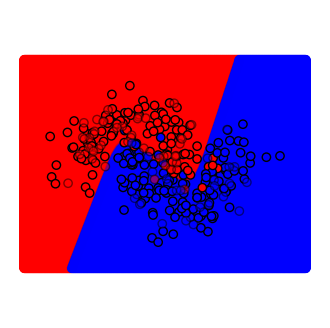

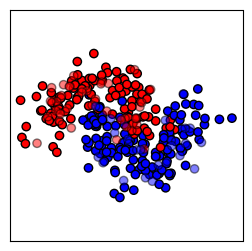

In [185]:
# Plot classification boundary
x_min, x_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
y_min, y_max = X[:, 2].min() - 0.5, X[:, 2].max() + 0.5
h = 0.005


Xp = []
for x in np.arange(x_min, x_max, h):
    for y in np.arange(y_min, y_max, h):
        Xp.append([1, x, y])

Xp = np.atleast_2d(Xp).T
yy = nn.predict(Xp)
yp = np.int64(yy > 0.5)      

figure = plt.figure(figsize=(4, 4))
cm = plt.cm.RdBu
cm_bright = ListedColormap(["#FF0000", "#0000FF"])
ax = plt.subplot(1, 1, 1)
ax.scatter(Xp.T[:,1], Xp.T[:, 2], c=yy.T, cmap=cm_bright, alpha=0.4,)

ax.scatter(X_train.T[:,1], X_train.T[:, 2], c=t_train.T, cmap=cm_bright, edgecolors="k")
ax.scatter(X_test.T[:, 1], X_test.T[:, 2], c=t_test.T, cmap=cm_bright, alpha=0.5, edgecolors="k")
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xticks(())
ax.set_yticks(())
ax.axis('equal');
ax.axis('off')

figure = plt.figure(figsize=(3, 3))
cm = plt.cm.RdBu
cm_bright = ListedColormap(["#FF0000", "#0000FF"])
ax = plt.subplot(1, 1, 1)
ax.scatter(X_train.T[:,1], X_train.T[:, 2], c=t_train.T, cmap=cm_bright, edgecolors="k")
ax.scatter(X_test.T[:, 1], X_test.T[:, 2], c=t_test.T, cmap=cm_bright, alpha=0.5, edgecolors="k")
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xticks(())
ax.set_yticks(())
ax.axis('equal');


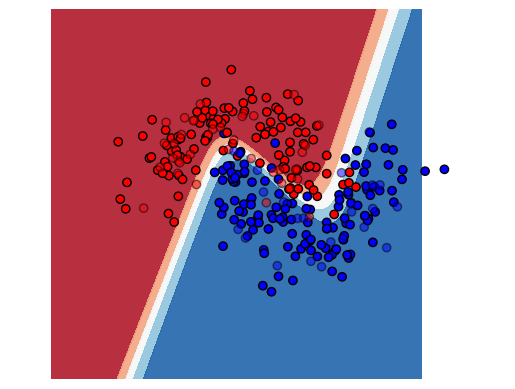

In [186]:
# Contour plot
h = 0.01
xx, yy = np.meshgrid(np.arange(-2.5, 2.5, h), np.arange(-2.5, 2.5, h))


XY = []
for x in np.arange(-2.5, 2.5, h):
    for y in np.arange(-2.5, 2.5, h):
        XY.append([1, x, y])

XY = np.array(XY).T
Z = np.array(nn.predict(XY))
Z=Z.reshape(xx.shape).T


plt.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.9, levels = 5)
plt.scatter(X_train.T[:,1], X_train.T[:, 2], c=t_train.T, cmap=cm_bright, edgecolors="k")
plt.scatter(X_test.T[:, 1], X_test.T[:, 2], c=t_test.T, cmap=cm_bright, alpha=0.5, edgecolors="k")
plt.axis('equal');
plt.axis('off');
plt.show()

In [187]:
print(nn.pack())

{'W1': array([[ 2.40755990e-02,  1.57030318e-01,  2.71256348e-02],
       [-1.39926275e-01,  5.62653870e-01, -1.56129936e-01],
       [-9.68330779e-02,  5.31405500e-01, -1.31980053e-01],
       [-5.95900962e-01,  7.66449146e-01, -2.62272582e-01],
       [-7.32778039e-02,  5.12766180e-01, -1.19524693e-01],
       [-6.77131436e-01,  7.95437470e-01, -2.57188796e-01],
       [ 5.16778496e-01, -7.23804000e-01,  2.45489597e-01],
       [ 1.14763704e-02, -3.38535423e-01,  1.76548637e-02],
       [ 5.43514106e-01, -7.27265946e-01,  2.32100186e-01],
       [-4.46039088e-01,  7.00389034e-01, -2.32165890e-01],
       [ 5.28385475e-01, -7.22122135e-01,  2.33654197e-01],
       [ 3.24939186e-01, -6.28197084e-01,  1.89558417e-01],
       [ 3.70886646e-02, -4.10658857e-01,  4.79346259e-02],
       [-3.54829205e+00,  5.90521555e+00,  3.48349962e+00],
       [ 3.99507601e-01, -6.63436325e-01,  2.09144172e-01],
       [-3.78409916e-01,  6.73098386e-01, -2.22111578e-01],
       [ 1.04773878e-02, -3.41720